<a href="https://colab.research.google.com/github/SholbanDongak/colab/blob/main/10_Bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Блок 1. Gaussian Naive Bayes

### 1. Постановка задачи

**Дано:** классический датасет ирисов Фишера (`load_iris`).

- $N = 150$ объектов (по 50 на класс)
- $d = 4$ вещественных признака:
  - $x_1$ — длина чашелистика (sepal length),
  - $x_2$ — ширина чашелистика (sepal width),
  - $x_3$ — длина лепестка (petal length),
  - $x_4$ — ширина лепестка (petal width).
- $K = 3$ класса (setosa, versicolor, virginica).

**Цель:** построить классификатор, разделяющий три вида ирисов, и проинтерпретировать его параметры.

---

### 2. Математическая модель

#### Наивное предположение
Признаки условно независимы при известном классе:

$$
p(\mathbf{x} \mid Y = k) = \prod_{j=1}^{4} g_{kj}(x_j).
$$

#### Гауссовская параметризация
Каждый признак внутри класса распределён нормально:

$$
g_{kj}(x_j) = \frac{1}{\sqrt{2\pi\sigma_{kj}^2}} \exp\left( -\frac{(x_j - \mu_{kj})^2}{2\sigma_{kj}^2} \right).
$$

- $\mu_{kj}$ — среднее значение $j$-го признака в $k$-м классе,
- $\sigma_{kj}^2$ — дисперсия $j$-го признака в $k$-м классе.

Всего $2 \cdot K \cdot d = 2 \cdot 3 \cdot 4 = 24$ параметра.

#### Решающее правило (MAP)

$$
\hat{y} = \arg\max_k \left[ \ln \pi_k - \frac{1}{2} \sum_{j=1}^{4} \left( \frac{(x_j - \mu_{kj})^2}{\sigma_{kj}^2} + \ln(2\pi\sigma_{kj}^2) \right) \right].
$$

#### Оценка параметров (MLE)
Для класса $k$ ($S_k$ — множество индексов объектов класса $k$, $N_k = |S_k|$):

$$
\hat{\pi}_k = \frac{N_k}{N}, \qquad
\hat{\mu}_{kj} = \frac{1}{N_k} \sum_{i \in S_k} x_{ij}, \qquad
\hat{\sigma}_{kj}^2 = \frac{1}{N_k} \sum_{i \in S_k} (x_{ij} - \hat{\mu}_{kj})^2.
$$

Accuracy (test): 0.911
Confusion matrix:
[[15  0  0]
 [ 0 14  1]
 [ 0  3 12]]


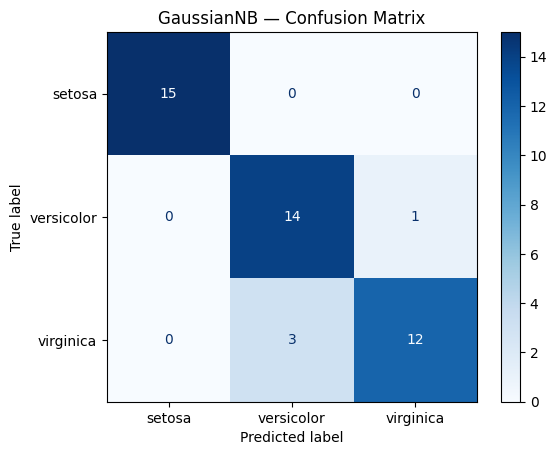

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.inspection import DecisionBoundaryDisplay

# Загрузка данных
iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names
class_names = iris.target_names

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Обучение GaussianNB
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Предсказание и метрики
y_pred = gnb.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy (test): {acc:.3f}")
print(f"Confusion matrix:\n{cm}")

ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap='Blues')
plt.title("GaussianNB — Confusion Matrix")
plt.show()

### 3. Визуализация: области решений (PCA до 2D)

### 3. Визуализация: области решений

У нас есть классификатор `gnb`, обученный на **полных** 4-мерных данных. Хотим посмотреть на границы решений. Проблема: нарисовать 4-мерное пространство нельзя. Нужно снизить размерность до 2D.

**Как делать нельзя (дидактический антипример):**

Обучить новый GaussianNB на 2D-проекции и нарисовать его границы. Тогда accuracy на графике будет соответствовать картинке — но это accuracy **другой** модели, не той, которую мы построили и оценивали. Выводы о качестве классификатора, сделанные по такой картинке, будут неверны.

=== АНТИПРИМЕР: модель обучена на 2D-проекции ===
Accuracy этой модели (train): 0.886
Accuracy исходной модели  (test):  0.911
Это РАЗНЫЕ модели. Границы ниже — не про наш классификатор!



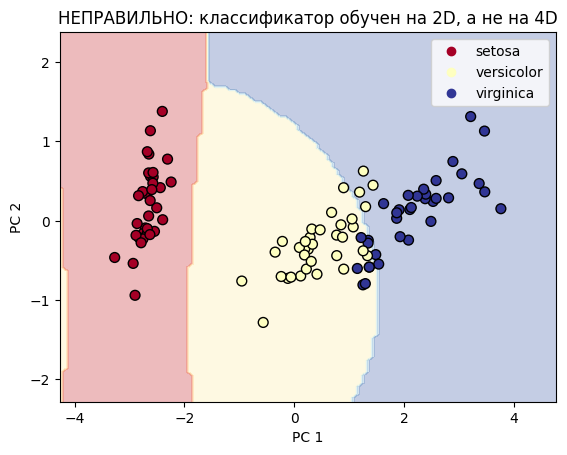

In [ ]:
# ============================================================
# АНТИПРИМЕР: как НЕ надо делать
# ============================================================
pca_bad = PCA(n_components=2)
X_train_2d = pca_bad.fit_transform(X_train)

gnb_2d = GaussianNB().fit(X_train_2d, y_train)
acc_2d = gnb_2d.score(X_train_2d, y_train)

print("=== АНТИПРИМЕР: модель обучена на 2D-проекции ===")
print(f"Accuracy этой модели (train): {acc_2d:.3f}")
print(f"Accuracy исходной модели  (test):  {acc:.3f}")
print("Это РАЗНЫЕ модели. Границы ниже — не про наш классификатор!\n")

DecisionBoundaryDisplay.from_estimator(
    gnb_2d, X_train_2d, response_method="predict",
    alpha=0.3, cmap=plt.cm.RdYlBu
)
scatter = plt.scatter(
    X_train_2d[:, 0], X_train_2d[:, 1],
    c=y_train, cmap=plt.cm.RdYlBu, edgecolor='k', s=50
)
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title("НЕПРАВИЛЬНО: классификатор обучен на 2D, а не на 4D")
plt.legend(handles=scatter.legend_elements()[0], labels=list(class_names))
plt.show()

**Почему это плохо?** Пользователь видит картинку и думает, что это границы «нашего» классификатора. На самом деле это границы **другой** модели, обученной на усечённых данных. Accuracy отличаются, выводы могут быть ошибочны.

**Как надо:** классификатор уже обучен на 4D. Для визуализации проецируем **точки** в 2D (через PCA), а границу решений строим так: покрываем 2D-пространство сеткой, каждую точку сетки поднимаем обратно в 4D (через `inverse_transform`), прогоняем через **исходный** 4D-классификатор, и раскрашиваем.

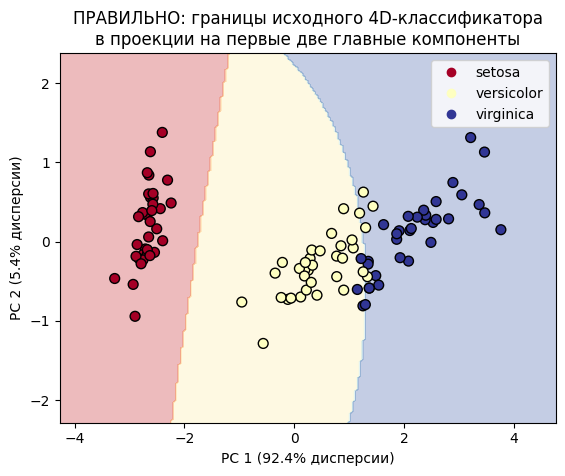

Доля объяснённой дисперсии (2 ГК): 0.978
Accuracy исходной 4D-модели (test): 0.911
Границы приближённые: часть информации потеряна при сжатии 4D → 2D.
Если доля объяснённой дисперсии мала, картинка может быть обманчивой.


In [ ]:
# ============================================================
# ПРАВИЛЬНО: визуализация 4D-классификатора через PCA
# ============================================================
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

# Сетка в 2D-пространстве главных компонент
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Поднимаем точки сетки обратно в 4D
grid_2d = np.c_[xx.ravel(), yy.ravel()]
grid_4d = pca.inverse_transform(grid_2d)

# Прогоняем через ИСХОДНЫЙ классификатор (обученный на 4D)
Z = gnb.predict(grid_4d)
Z = Z.reshape(xx.shape)

# Рисуем
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
scatter = plt.scatter(
    X_train_pca[:, 0], X_train_pca[:, 1],
    c=y_train, cmap=plt.cm.RdYlBu, edgecolor='k', s=50
)
plt.xlabel(f"PC 1 ({pca.explained_variance_ratio_[0]:.1%} дисперсии)")
plt.ylabel(f"PC 2 ({pca.explained_variance_ratio_[1]:.1%} дисперсии)")
plt.title("ПРАВИЛЬНО: границы исходного 4D-классификатора\nв проекции на первые две главные компоненты")
plt.legend(handles=scatter.legend_elements()[0], labels=list(class_names))
plt.show()

explained_var = pca.explained_variance_ratio_.sum()
print(f"Доля объяснённой дисперсии (2 ГК): {explained_var:.3f}")
print(f"Accuracy исходной 4D-модели (test): {acc:.3f}")
print("Границы приближённые: часть информации потеряна при сжатии 4D → 2D.")
print("Если доля объяснённой дисперсии мала, картинка может быть обманчивой.")

**Что мы сделали:**
1. Обучили PCA на обучающих данных;
2. Спроецировали обучающие точки в 2D — только для визуализации;
3. Создали плотную сетку в 2D-пространстве главных компонент;
4. Каждую точку сетки подняли обратно в 4D через `pca.inverse_transform`;
5. Пропустили через **исходный** 4D-классификатор `gnb` — тот самый, accuracy которого мы измеряли;
6. Раскрасили сетку предсказаниями.

**Важно:** границы на графике — это проекция истинных 4D-границ на плоскость первых двух главных компонент. Если бы PCA объяснял малую долю дисперсии, классы на графике могли бы выглядеть перемешанными — при том, что в 4D они отлично разделены. Для ирисов первые две компоненты объясняют >95% дисперсии, поэтому картинка адекватна.

**Дидактический итог:**
- Нельзя обучать модель на данных меньшей размерности и выдавать её за исходную;
- Визуализация многомерного классификатора — нетривиальная задача;
- PCA + `inverse_transform` — корректный способ посмотреть на границы решений в 2D.

### 4. Интерпретация: параметры модели

In [ ]:
# Априорные вероятности классов
print("Априорные вероятности классов (π_k):")
for k, name in enumerate(class_names):
    print(f"  {name}: {gnb.class_prior_[k]:.3f}")

# Средние значения признаков по классам
print("\nСредние значения признаков (μ_kj):")
print("Признак".ljust(20), end="")
for name in class_names:
    print(f"{name}".rjust(12), end="")
print()
for j, fname in enumerate(feature_names):
    print(fname.ljust(20), end="")
    for k in range(3):
        print(f"{gnb.theta_[k, j]:8.3f}   ", end="")
    print()

# Дисперсии признаков по классам
print("\nДисперсии признаков (σ²_kj):")
print("Признак".ljust(20), end="")
for name in class_names:
    print(f"{name}".rjust(12), end="")
print()
for j, fname in enumerate(feature_names):
    print(fname.ljust(20), end="")
    for k in range(3):
        print(f"{gnb.var_[k, j]:8.3f}   ", end="")
    print()

Априорные вероятности классов (π_k):
  setosa: 0.333
  versicolor: 0.333
  virginica: 0.333

Средние значения признаков (μ_kj):
Признак                   setosa  versicolor   virginica
sepal length (cm)      4.989      5.949      6.683   
sepal width (cm)       3.426      2.731      3.009   
petal length (cm)      1.486      4.237      5.631   
petal width (cm)       0.240      1.309      2.069   

Дисперсии признаков (σ²_kj):
Признак                   setosa  versicolor   virginica
sepal length (cm)      0.103      0.241      0.425   
sepal width (cm)       0.174      0.086      0.117   
petal length (cm)      0.023      0.211      0.323   
petal width (cm)       0.009      0.036      0.064   


**Вопросы для анализа:**
1. Какие признаки имеют наибольший разброс средних значений между классами? (Они лучше всего разделяют классы.)
2. У какого класса дисперсии в среднем меньше? О чём это говорит?
3. Почему классификатор на ирисах работает почти идеально, несмотря на наивное предположение?


### 5. Бонус: predict_proba для пограничного объекта

In [ ]:
# Находим объект, где модель сомневается
probas = gnb.predict_proba(X_test)
max_proba = probas.max(axis=1)
borderline_idx = np.argmin(max_proba)  # объект с минимальной уверенностью

x_border = X_test[borderline_idx]
y_border_true = y_test[borderline_idx]
y_border_pred = y_pred[borderline_idx]
proba_border = probas[borderline_idx]

print(f"Пограничный объект (индекс {borderline_idx} в test):")
print(f"  Истинный класс: {class_names[y_border_true]}")
print(f"  Предсказанный класс: {class_names[y_border_pred]}")
print(f"  Вероятности классов:")
for k, name in enumerate(class_names):
    print(f"    {name}: {proba_border[k]:.4f}")

Пограничный объект (индекс 3 в test):
  Истинный класс: versicolor
  Предсказанный класс: versicolor
  Вероятности классов:
    setosa: 0.0000
    versicolor: 0.6680
    virginica: 0.3320


**Вывод:** байесовский классификатор не просто выдаёт метку — он сообщает **степень уверенности** в ответе. Для пограничных объектов вероятности классов близки друг к другу.

# Блок 2. Multinomial Naive Bayes

### 1. Постановка задачи

**Дано:** подмножество датасета `fetch_20newsgroups` — тексты новостей по четырём тематикам.

- $N \approx 3000$ документов (после фильтрации)
- $K = 4$ категории:
  - `alt.atheism` — атеизм,
  - `soc.religion.christian` — христианство,
  - `comp.graphics` — компьютерная графика,
  - `sci.space` — космос.
- Тексты на английском языке, разной длины.

**Цель:** построить классификатор новостей по темам, исследовать влияние сглаживания Лапласа и проинтерпретировать ключевые слова-индикаторы для каждой темы.

---

### 2. Математическая модель

#### Предобработка: мешок слов (Bag-of-Words)
Каждый документ превращается в вектор $\mathbf{x} \in \mathbb{N}_0^d$, где:

- $d$ — размер словаря (количество уникальных слов во всех документах),
- $x_j$ — сколько раз слово $j$ встретилось в данном документе.

#### Мультиномиальное распределение
Вектор признаков моделируется мультиномиальным распределением:

$$
p(\mathbf{x} \mid Y = k) = \frac{\bigl(\sum_{j=1}^{d} x_j\bigr)!}{\prod_{j=1}^{d} x_j!} \prod_{j=1}^{d} \theta_{kj}^{x_j},
$$

где $\theta_{kj} = P(\text{слово } j \mid Y = k)$, и для каждого класса $\sum_{j=1}^{d} \theta_{kj} = 1$.

#### Решающее правило (MAP)
Мультиномиальный коэффициент не зависит от $k$, поэтому сокращается:

$$
\hat{y} = \arg\max_k \left[ \ln \pi_k + \sum_{j=1}^{d} x_j \ln \theta_{kj} \right].
$$

Слагаемое $x_j \ln \theta_{kj}$ — это вклад слова $j$ в пользу класса $k$. Слова, которых нет в документе ($x_j = 0$), вклада не дают.

#### Оценка параметров со сглаживанием Лапласа
Без сглаживания ($\alpha = 0$) — чистый MLE:

$$
\hat{\theta}_{kj}^{(0)} = \frac{\sum_{i \in S_k} x_{ij}}{\sum_{i \in S_k} \sum_{\ell=1}^{d} x_{i\ell}}.
$$

Со сглаживанием Лапласа ($\alpha > 0$):

$$
\hat{\theta}_{kj}^{(\alpha)} = \frac{\sum_{i \in S_k} x_{ij} + \alpha}{\sum_{i \in S_k} \sum_{\ell=1}^{d} x_{i\ell} + \alpha d}.
$$

- $\alpha$ — гиперпараметр, интерпретируется как «псевдоколичество»: сколько раз мы априори «видели» каждое слово в каждом классе.
- $\alpha = 1$ — классическое сглаживание Лапласа (равномерное априорное распределение Дирихле).
- $\alpha \to 0$ — чисто частотная оценка (MLE), опасна нулевыми вероятностями.
- $\alpha \gg 1$ — сильное сглаживание, все вероятности $\theta_{kj}$ стремятся к $1/d$.

In [ ]:
# Загрузка и предобработка
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

categories = ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.space']

# Загружаем train и test отдельно (как задумано в 20newsgroups)
news_train = fetch_20newsgroups(subset='train', categories=categories, random_state=42)
news_test  = fetch_20newsgroups(subset='test',  categories=categories, random_state=42)

print(f"Train: {len(news_train.data)} документов")
print(f"Test:  {len(news_test.data)} документов")
print(f"Категории: {news_train.target_names}")

# Bag-of-Words
vectorizer = CountVectorizer(stop_words='english')
X_train = vectorizer.fit_transform(news_train.data)
X_test  = vectorizer.transform(news_test.data)
y_train, y_test = news_train.target, news_test.target
d = X_train.shape[1]
print(f"Размер словаря: {d} слов")

Train: 2256 документов
Test:  1500 документов
Категории: ['alt.atheism', 'comp.graphics', 'sci.space', 'soc.religion.christian']
Размер словаря: 34986 слов


### 3. Влияние сглаживания Лапласа

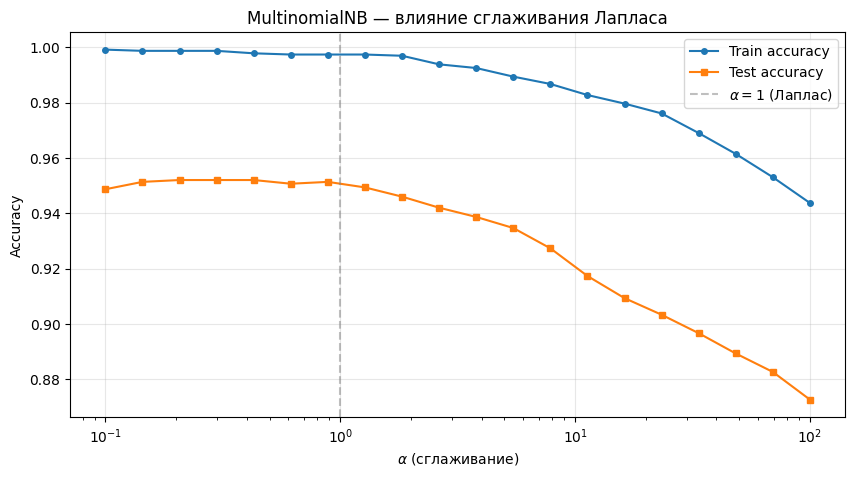

Лучшее alpha: 0.207, accuracy (test): 0.952


In [ ]:
# Подбор alpha по логарифмической сетке
alphas = np.logspace(-1, 2, 20)  # от 0.1 до 100
train_scores, test_scores = [], []

for a in alphas:
    mnb = MultinomialNB(alpha=a)
    mnb.fit(X_train, y_train)
    train_scores.append(mnb.score(X_train, y_train))
    test_scores.append(mnb.score(X_test, y_test))

# График
plt.figure(figsize=(10, 5))
plt.semilogx(alphas, train_scores, 'o-', label='Train accuracy', markersize=4)
plt.semilogx(alphas, test_scores,  's-', label='Test accuracy',  markersize=4)
plt.axvline(1.0, color='gray', linestyle='--', alpha=0.5, label=r'$\alpha = 1$ (Лаплас)')
plt.xlabel(r'$\alpha$ (сглаживание)')
plt.ylabel('Accuracy')
plt.title('MultinomialNB — влияние сглаживания Лапласа')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Оптимальное alpha
best_alpha = alphas[np.argmax(test_scores)]
print(f"Лучшее alpha: {best_alpha:.3f}, accuracy (test): {max(test_scores):.3f}")

**Анализ графика:**

- При малых $\alpha$ train accuracy чуть выше, чем при больших — модель точнее подстраивается под обучающие данные.
- Однако test accuracy **не растёт** при $\alpha \to 0$: переобучения нет. Почему?
  - Датасет достаточно велик ($N \approx 3000$), и нулевые частоты слов встречаются редко, поэтому MLE-оценки и так стабильны.
  - Основная опасность MLE — нулевые вероятности для слов, которых нет в обучении, но есть в тесте. Здесь таких слов немного.
- При $\alpha \to 100$: и train, и test accuracy монотонно падают — **недообучение**. Сильное сглаживание «замыливает» различия между классами: все $\theta_{kj}$ стремятся к $1/d$.
- $\alpha = 1$ (Лаплас) даёт практически тот же результат, что и оптимальное $\alpha$ — модель устойчива к выбору гиперпараметра.
- **Мораль:** на больших и чистых текстовых датасетах сглаживание Лапласа — безопасный выбор по умолчанию. Оптимизация $\alpha$ даёт лишь незначительный прирост.

### 4. Итоговая модель и матрица ошибок

Accuracy (test): 0.952


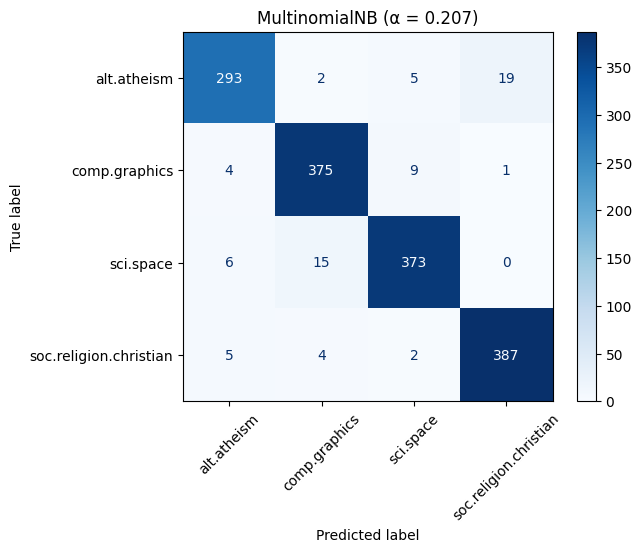

In [ ]:
# Обучаем с лучшим alpha
best_mnb = MultinomialNB(alpha=best_alpha)
best_mnb.fit(X_train, y_train)
y_pred = best_mnb.predict(X_test)

print(f"Accuracy (test): {accuracy_score(y_test, y_pred):.3f}")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=news_train.target_names,
    cmap='Blues', xticks_rotation=45
)
plt.title(f"MultinomialNB (α = {best_alpha:.3f})")
plt.show()

### 5. Интерпретация: топ-слова для каждой темы

In [ ]:
feature_names = vectorizer.get_feature_names_out()

# Логарифм вероятностей log P(word | class) = log θ_kj
log_prob = best_mnb.feature_log_prob_

n_top = 10  # сколько слов показать

for k, category in enumerate(news_train.target_names):
    top_idx = np.argsort(log_prob[k])[-n_top:][::-1]
    print(f"\n{'='*60}")
    print(f"Тема: {category}")
    print(f"{'='*60}")
    print(f"{'Слово':<20} {'log θ_kj':>10} {'θ_kj':>10}")
    print(f"{'-'*40}")
    for idx in top_idx:
        word = feature_names[idx]
        print(f"{word:<20} {log_prob[k, idx]:>10.3f} {np.exp(log_prob[k, idx]):>10.6f}")


Тема: alt.atheism
Слово                  log θ_kj       θ_kj
----------------------------------------
edu                      -4.325   0.013239
god                      -4.859   0.007756
people                   -5.066   0.006308
writes                   -5.087   0.006177
com                      -5.099   0.006100
subject                  -5.134   0.005891
lines                    -5.184   0.005606
don                      -5.295   0.005014
organization             -5.298   0.005003
article                  -5.394   0.004543

Тема: comp.graphics
Слово                  log θ_kj       θ_kj
----------------------------------------
edu                      -4.482   0.011311
lines                    -4.957   0.007036
subject                  -4.988   0.006818
graphics                 -5.022   0.006589
organization             -5.071   0.006273
image                    -5.149   0.005804
com                      -5.371   0.004648
university               -5.542   0.003917
posting           

### 5. Интерпретация: топ-слова для каждой темы

**Результат:**
- Тема `alt.atheism` (атеизм) — топ: `edu`, `god`, `people`, `writes`, `com`, `subject`, `lines`, `don`, `organization`, `article`.
- Тема `comp.graphics` (графика) — топ: `edu`, `lines`, `subject`, `graphics`, `organization`, `image`, `com`, `university`, `posting`, `file`.
- Тема `sci.space` (космос) — топ: `space`, `edu`, `nasa`, `subject`, `organization`, `lines`, `com`, `writes`, `article`, `gov`.
- Тема `soc.religion.christian` (христианство) — топ: `god`, `edu`, `subject`, `people`, `jesus`, `lines`, `organization`, `think`, `know`, `church`.

**Что бросается в глаза?**

Слова `edu`, `lines`, `subject`, `organization`, `com`, `writes`, `article` присутствуют в топ-10 **всех** четырёх тем! Это технический «мусор» — заголовки и подписи из структуры новостных сообщений (e-mail заголовки, строки форматирования). Они не несут смысловой нагрузки для разделения тем.

**Почему так вышло?**

Потому что мы не удалили эти слова. В оригинальных данных 20 Newsgroups каждое сообщение содержит технические поля:
- `From:`, `Subject:`, `Organization:`, `Lines:`, `X-Newsreader:` и т.д.
- Домены электронной почты (`edu`, `com`, `writes` из адресов).

Эти слова встречаются часто во всех темах и, хотя не помогают классификации, получают высокие вероятности $\theta_{kj}$ из-за общей частотности.

**Как правильно?**

В данных `fetch_20newsgroups` есть параметр `remove=('headers', 'footers', 'quotes')`, который удаляет технические заголовки, подписи и цитирование. Этим нужно было воспользоваться при загрузке данных!

**Но даже в таком «грязном» виде:**
- `sci.space` — слово `space` на 1-м месте, `nasa` на 3-м, `gov` на 10-м — осмысленно.
- `comp.graphics` — `graphics` на 4-м, `image` на 6-м, `file` на 10-м — видно тематическое ядро.
- `alt.atheism` — `god` на 2-м месте (полемика о боге), `don` — вероятно, часть `don't`, характерного для дискуссий.
- `soc.religion.christian` — `god` на 1-м, `jesus` на 5-м, `church` на 10-м — явно религиозная лексика.

Тематические слова пробиваются сквозь технический шум — модель всё равно работает. Но качество классификации можно улучшить, очистив данные.

### Исправленная загрузка данных (демонстрация)

Вот как нужно было загружать данные с очисткой:

In [ ]:
# Правильная загрузка — без заголовков, подписей и цитирования
news_train_clean = fetch_20newsgroups(
    subset='train', categories=categories,
    remove=('headers', 'footers', 'quotes'),
    random_state=42
)
news_test_clean = fetch_20newsgroups(
    subset='test', categories=categories,
    remove=('headers', 'footers', 'quotes'),
    random_state=42
)

# Повторяем векторизацию и обучение
X_train_c = vectorizer.fit_transform(news_train_clean.data)
X_test_c  = vectorizer.transform(news_test_clean.data)

mnb_clean = MultinomialNB(alpha=best_alpha)
mnb_clean.fit(X_train_c, news_train_clean.target)
acc_clean = mnb_clean.score(X_test_c, news_test_clean.target)

print(f"Accuracy без очистки: {best_mnb.score(X_test, y_test):.3f}")
print(f"Accuracy с очисткой:   {acc_clean:.3f}")

# Топ-слова для sci.space после очистки
log_prob_c = mnb_clean.feature_log_prob_
feature_names_c = vectorizer.get_feature_names_out()
space_idx = list(news_train_clean.target_names).index('sci.space')

print(f"\nТема: sci.space (после очистки)")
top_idx = np.argsort(log_prob_c[space_idx])[-10:][::-1]
for idx in top_idx:
    w = feature_names_c[idx]
    print(f"  {w:<15}  log θ = {log_prob_c[space_idx, idx]:.3f}")

Accuracy без очистки: 0.952
Accuracy с очисткой:   0.833

Тема: sci.space (после очистки)
  space            log θ = -4.308
  nasa             log θ = -5.280
  launch           log θ = -5.616
  like             log θ = -5.801
  earth            log θ = -5.801
  data             log θ = -5.828
  orbit            log θ = -5.900
  time             log θ = -5.920
  shuttle          log θ = -5.946
  just             log θ = -5.962


**Результат после очистки:**

- Accuracy без очистки: **0.952**
- Accuracy с очисткой: **0.833**
- Топ-слова для `sci.space`: `space`, `nasa`, `launch`, `like`, `earth`, `data`, `orbit`, `time`, `shuttle`, `just`.

**Почему accuracy упала?**

Это принципиальный момент. Раньше, с заголовками, модель «жульничала». Она находила технические паттерны, специфичные для разных групп новостей:

- В новостях `sci.space` часто цитировались пресс-релизы NASA — характерная структура заголовков, определённые почтовые домены.
- В религиозных новостях — другие источники, другие signatures.

Модель с высокой точностью (0.952) классифицировала **не тему** текста, а **источник** или **формат** сообщения. Это классический пример **data leakage** — утечки информации через побочные признаки.

После удаления заголовков модель вынуждена классифицировать **по содержанию**, и accuracy падает до 0.833 — это честная оценка качества содержательной классификации.

**Анализ топ-слов для `sci.space` после очистки:**

Теперь картина намного чище:
- `space`, `nasa`, `launch`, `earth`, `orbit`, `shuttle` — тематическая лексика, прямо связанная с космосом.
- `data` — научные данные, обсуждаемые в контексте космических миссий.
- `like`, `just`, `time` — общеупотребительные слова, которые всё же чаще встречаются в научно-технических дискуссиях.

**Важный урок:**

1. **Высокая accuracy — не всегда хорошо.** Нужно проверять, на каких признаках модель принимает решение.
2. **Интерпретируемость наивного Байеса — его суперсила.** Просмотр $\theta_{kj}$ позволил нам мгновенно обнаружить проблему с заголовками. Модели типа нейронных сетей такой прозрачности не дают.
3. **Предобработка данных критична.** Параметр `remove=('headers', 'footers', 'quotes')` в `fetch_20newsgroups` существует именно потому, что исследователи уже наступали на эти грабли.
4. **0.833 — достойный результат** для мультиклассовой классификации текстов (4 класса, случайный baseline — 0.25). Дальнейшее улучшение потребовало бы более сложных моделей или дополнительной предобработки (стемминг, TF-IDF вместо CountVectorizer).

**Общий вывод по MultinomialNB:**
1. Модель работает, даже когда данные «грязные» — но может решать не ту задачу, которую мы думаем.
2. Сглаживание Лапласа необходимо: без него редкие слова получают нулевые вероятности и разрушают классификацию.
3. Наивный Байес — интерпретируемая модель: просматривая $\theta_{kj}$, мы видим, какие слова модель считает характерными для каждой темы, и можем обнаружить проблемы в данных.
4. Качество модели напрямую зависит от качества предобработки текста.

# Блок 3. Bernoulli Naive Bayes

### 1. Постановка задачи

**Дано:** те же тексты новостей (`fetch_20newsgroups`, 4 категории), что и в предыдущем блоке, но с другой предобработкой.

- $N \approx 3000$ документов (после фильтрации)
- $K = 4$ категории: `alt.atheism`, `soc.religion.christian`, `comp.graphics`, `sci.space`
- $d$ — размер словаря (тот же, что и в MultinomialNB)

**Отличие от блока 2:** признаки — не частоты слов, а бинарные индикаторы их наличия.

**Цель:** сравнить Bernoulli Naive Bayes с Multinomial Naive Bayes, понять, в каких ситуациях бинарная модель предпочтительнее, и выявить разницу в интерпретации параметров.

---

### 2. Математическая модель

#### Предобработка: бинарный мешок слов
Каждый документ превращается в вектор $\mathbf{x} \in \{0, 1\}^d$, где:

$$
x_j = \begin{cases}
1, & \text{если слово } j \text{ встретилось в документе хотя бы один раз},\\
0, & \text{если слово } j \text{ не встретилось}.
\end{cases}
$$

В отличие от MultinomialNB, кратность слова игнорируется: слово либо есть, либо нет.

#### Распределение Бернулли
Каждый признак моделируется независимым бернуллиевским распределением:

$$
g_{kj}(x_j) = p_{kj}^{x_j} (1 - p_{kj})^{1 - x_j}, \qquad p_{kj} = P(X_j = 1 \mid Y = k).
$$

- $p_{kj}$ — вероятность того, что слово $j$ появится в документе класса $k$ (хотя бы раз).

#### Решающее правило (MAP)
Подставляем бернуллиевские вероятности в логарифмическую форму. В отличие от мультиномиальной модели, здесь **учитываются и отсутствующие слова** (через слагаемое $\ln(1 - p_{kj})$ при $x_j = 0$):

$$
\hat{y} = \arg\max_k \left[ \ln \pi_k + \sum_{j=1}^{d} \Bigl( x_j \ln p_{kj} + (1 - x_j) \ln(1 - p_{kj}) \Bigr) \right].
$$

Это принципиальное отличие: **отсутствие ожидаемого слова — тоже сигнал**.

#### Оценка параметров со сглаживанием Лапласа
Без сглаживания ($\alpha = 0$) — MLE:

$$
\hat{p}_{kj}^{(0)} = \frac{\text{число документов класса } k \text{, содержащих слово } j}{N_k}.
$$

Со сглаживанием Лапласа ($\alpha > 0$):

$$
\hat{p}_{kj}^{(\alpha)} = \frac{\text{count}_k(j) + \alpha}{N_k + 2\alpha}.
$$

- Знаменатель $N_k + 2\alpha$, а не $N_k + \alpha d$ — потому что для каждого слова оценивается один параметр $p_{kj}$, а не вектор $\boldsymbol{\theta}_k$ на симплексе.
- $\alpha = 1$ — классическое сглаживание Лапласа.
- $\alpha \to 0$ — частотная оценка, опасна: $p_{kj} = 0$ или $p_{kj} = 1$ разрушают классификатор.

---

### 3. Сравнение MultinomialNB vs BernoulliNB

| Характеристика | MultinomialNB | BernoulliNB |
|----------------|---------------|-------------|
| Тип признаков | Счётчики ($x_j \in \mathbb{N}_0$) | Бинарные ($x_j \in \{0, 1\}$) |
| Учитывает кратность слова | Да | Нет |
| Учитывает отсутствие слова | Нет ($x_j=0 \Rightarrow$ вклад 0) | **Да** (через $\ln(1-p_{kj})$) |
| Число параметров | $K \cdot d$ (вектор $\boldsymbol{\theta}_k$) | $K \cdot d$ (матрица $p_{kj}$) |
| Хорош для | Длинных документов | Коротких документов |
| Пример | Классификация статей | Классификация твитов, SMS |

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import BernoulliNB, MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

categories = ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.space']

# Загрузка с очисткой (урок из предыдущего блока)
news_train = fetch_20newsgroups(
    subset='train', categories=categories,
    remove=('headers', 'footers', 'quotes'), random_state=42
)
news_test = fetch_20newsgroups(
    subset='test', categories=categories,
    remove=('headers', 'footers', 'quotes'), random_state=42
)

# Два векторизатора: обычный и бинарный
vec_count  = CountVectorizer(stop_words='english')
vec_binary = CountVectorizer(stop_words='english', binary=True)

### 4. Сравнение при разных объёмах обучающей выборки

Обучим обе модели на подвыборках разного размера (от 5% до 100% обучающих данных) и сравним кривые обучения.

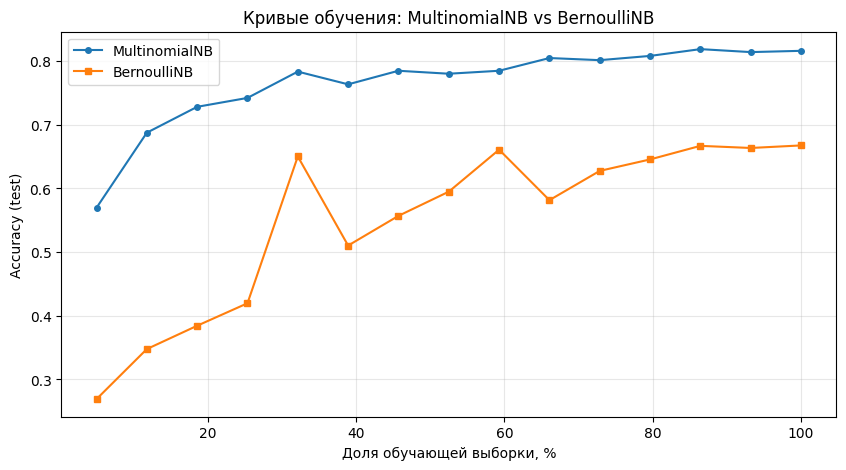

In [ ]:
X_train_full = vec_count.fit_transform(news_train.data)
X_test_full  = vec_count.transform(news_test.data)
y_train_full, y_test_full = news_train.target, news_test.target

X_train_bin = vec_binary.fit_transform(news_train.data)
X_test_bin  = vec_binary.transform(news_test.data)

# Доли обучающей выборки
train_sizes = np.linspace(0.05, 1.0, 15)
scores_multi, scores_bern = [], []

for size in train_sizes:
    n_samples = int(len(y_train_full) * size)
    idx = np.random.choice(len(y_train_full), n_samples, replace=False)

    # Multinomial
    mnb = MultinomialNB(alpha=1.0)
    mnb.fit(X_train_full[idx], y_train_full[idx])
    scores_multi.append(mnb.score(X_test_full, y_test_full))

    # Bernoulli
    bnb = BernoulliNB(alpha=1.0)
    bnb.fit(X_train_bin[idx], y_train_full[idx])
    scores_bern.append(bnb.score(X_test_bin, y_test_full))

plt.figure(figsize=(10, 5))
plt.plot(train_sizes * 100, scores_multi, 'o-', label='MultinomialNB', markersize=4)
plt.plot(train_sizes * 100, scores_bern,  's-', label='BernoulliNB',  markersize=4)
plt.xlabel('Доля обучающей выборки, %')
plt.ylabel('Accuracy (test)')
plt.title('Кривые обучения: MultinomialNB vs BernoulliNB')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 5. Итоговое сравнение на полной выборке

MultinomialNB accuracy: 0.816
BernoulliNB   accuracy: 0.667


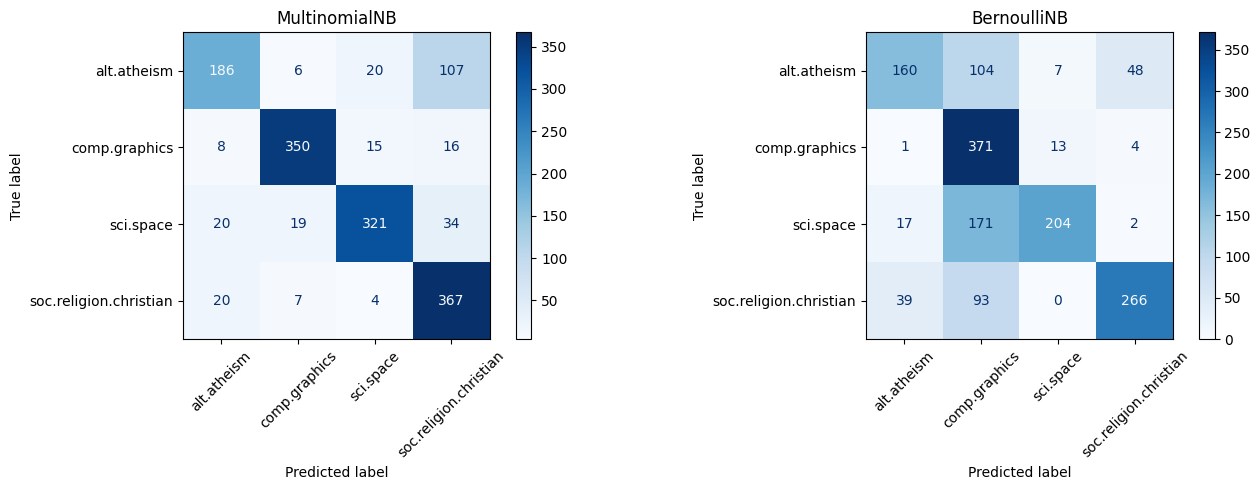

In [ ]:
# Обучаем на полных данных
mnb = MultinomialNB(alpha=1.0).fit(X_train_full, y_train_full)
bnb = BernoulliNB(alpha=1.0).fit(X_train_bin, y_train_full)

acc_multi = mnb.score(X_test_full, y_test_full)
acc_bern  = bnb.score(X_test_bin, y_test_full)

print(f"MultinomialNB accuracy: {acc_multi:.3f}")
print(f"BernoulliNB   accuracy: {acc_bern:.3f}")

# Матрицы ошибок — рядом
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_estimator(
    mnb, X_test_full, y_test_full,
    display_labels=news_train.target_names,
    cmap='Blues', xticks_rotation=45, ax=axes[0]
)
axes[0].set_title("MultinomialNB")

ConfusionMatrixDisplay.from_estimator(
    bnb, X_test_bin, y_test_full,
    display_labels=news_train.target_names,
    cmap='Blues', xticks_rotation=45, ax=axes[1]
)
axes[1].set_title("BernoulliNB")

plt.tight_layout()
plt.show()

### 4. Сравнение при разных объёмах обучающей выборки

**Результат:**

| Доля данных | MultinomialNB | BernoulliNB |
|-------------|---------------|-------------|
| 5%          | 0.569         | 0.269       |
| 20%         | 0.728         | 0.384       |
| 50%         | 0.763         | 0.510       |
| 100%        | 0.816         | 0.667       |

**Анализ кривых обучения:**

1. **MultinomialNB** быстро выходит на плато: уже на 20% данных accuracy достигает 0.73, а дальше растёт медленно — до 0.82. Модели хватает даже небольшой выборки.

2. **BernoulliNB** стартует почти со случайного угадывания (0.27 при 4 классах — близко к baseline 0.25) и растёт значительно медленнее. Даже на полной выборке accuracy лишь 0.67 — почти на 15 пунктов ниже мультиномиальной модели.

3. **Разрыв** между моделями сохраняется на всех размерах выборки. BernoulliNB не догоняет MultinomialNB.

---

### 5. Итоговое сравнение на полной выборке

- MultinomialNB accuracy: **0.816**
- BernoulliNB   accuracy: **0.667**

**Почему BernoulliNB так сильно проиграл?**

Это не ошибка — это фундаментальное свойство задачи. Новостные тексты `20newsgroups` **длинные** (сотни слов), и кратность слов несёт важную информацию. Конкретные причины:

1. **Длина документов.** В среднем несколько сотен слов. Если слово `space` встретилось 15 раз — это сильный сигнал. BernoulliNB видит только «да/нет» и теряет информацию об интенсивности.

2. **Дискурсивные слова.** В длинных текстах важны не только тематические термины, но и частота их употребления. В научно-технических текстах одни и те же термины повторяются многократно — и это информативно.

3. **Отсутствие слова — слабый сигнал.** В длинном тексте отсутствие конкретного слова почти ничего не говорит: словарь огромен ($d \sim 30\,000$), документ содержит лишь малую его часть. Бернуллиевский учёт отсутствий через $\ln(1-p_{kj})$ вносит много шума.

**Когда BernoulliNB был бы лучше?**

Классический сценарий — **короткие документы**:
- Твиты (до 280 символов);
- SMS (классический датасет spam/ham);
- Заголовки статей;
- Поисковые запросы.

В этих случаях:
- Слово редко встречается больше одного раза — кратность неинформативна;
- Отсутствие слова более значимо: если в твите нет хэштега, это сигнал;
- Документы содержат малую долю словаря — бинарная модель устойчивее.

**Вывод по сравнению:**

Результат не означает, что BernoulliNB «плохой». Он означает, что для **длинных новостных текстов** частоты слов важнее их простого наличия. MultinomialNB использует больше информации из данных и закономерно выигрывает. В следующем блоке мы увидим задачу, где BernoulliNB может оказаться конкурентоспособным.

### 6. Интерпретация: топ-слова для BernoulliNB

Посмотрим, какие слова BernoulliNB считает наиболее характерными для каждой темы. В отличие от MultinomialNB, здесь смотрим не на $\ln \theta_{kj}$, а на $\ln p_{kj} - \ln(1 - p_{kj})$ — логарифм шансов слова.

In [ ]:
feature_names = vec_binary.get_feature_names_out()
log_prob_b = bnb.feature_log_prob_   # log P(word=1 | class)
log_prob_neg_b = np.log(1 - np.exp(log_prob_b))  # log P(word=0 | class)

# Разница логарифмов: насколько наличие слова повышает лог-вероятность класса
# по сравнению с его отсутствием
log_odds = log_prob_b - log_prob_neg_b

n_top = 10
for k, category in enumerate(news_train.target_names):
    top_idx = np.argsort(log_odds[k])[-n_top:][::-1]
    print(f"\n{'='*60}")
    print(f"Тема: {category}")
    print(f"{'='*60}")
    print(f"{'Слово':<15} {'log (p/(1-p))':>15} {'p_kj':>10}")
    print(f"{'-'*45}")
    for idx in top_idx:
        word = feature_names[idx]
        print(f"{word:<15} {log_odds[k, idx]:>15.3f} {np.exp(log_prob_b[k, idx]):>10.4f}")


Тема: alt.atheism
Слово             log (p/(1-p))       p_kj
---------------------------------------------
don                      -0.824     0.3050
people                   -0.975     0.2739
think                    -1.104     0.2490
just                     -1.183     0.2344
say                      -1.278     0.2178
like                     -1.303     0.2137
god                      -1.353     0.2054
does                     -1.379     0.2012
know                     -1.379     0.2012
time                     -1.614     0.1660

Тема: comp.graphics
Слово             log (p/(1-p))       p_kj
---------------------------------------------
thanks                   -1.206     0.2304
graphics                 -1.235     0.2253
know                     -1.255     0.2218
like                     -1.378     0.2014
use                      -1.534     0.1775
does                     -1.545     0.1758
need                     -1.681     0.1570
program                  -1.707     0.1536
don     

### 6. Интерпретация: топ-слова для BernoulliNB

**Что показывает логарифм шансов $\ln \frac{p}{1-p}$:**

- Значение $\approx 0$: слово одинаково часто встречается и не встречается в документах класса.
- Значение $> 0$: слово повышает вероятность класса (индикатор).
- Значение $< 0$: слово **понижает** вероятность класса (анти-индикатор).

**Результат: все значения отрицательные!**

Даже самые «характерные» слова имеют $\ln \frac{p}{1-p} < 0$. Это означает, что **ни одно слово не встречается более чем в половине документов** какого-либо класса. Вспомним: $p_{kj}$ — это доля документов класса $k$, содержащих слово $j$.

- `sci.space`: слово `space` есть в 36% документов — это максимум.
- `soc.religion.christian`: слово `god` есть в 48% документов — самое высокое значение.
- `alt.atheism`: слово `god` есть лишь в 20% документов (полемика о боге, а не проповедь).
- `comp.graphics`: максимальная $p_{kj}$ около 23%.

Это **разреженные данные**: словарь огромен, а каждый документ содержит лишь малую долю слов. Даже самые тематические слова появляются менее чем в половине документов своего класса.

**Почему модель всё же работает (accuracy 0.67)?**

Потому что классификация строится на **разнице** между классами. Сравним слово `space`:
- В `sci.space`: $\ln \frac{p}{1-p} = -0.570$ ($p = 0.36$);
- В `soc.religion.christian`: $\ln \frac{p}{1-p}$ будет гораздо ниже ($p$ близко к 0).

Разница логарифмов шансов между классами и формирует решающее правило. Модель сравнивает, насколько слово **менее нехарактерно** для одного класса, чем для другого.

---

### 6а. Сравнение интерпретации: MultinomialNB vs BernoulliNB

**MultinomialNB — вероятности слов:**
- Параметры $\theta_{kj}$ интерпретируются как «вероятность вытащить слово $j$ из мешка слов класса $k$».
- Сумма $\sum_j \theta_{kj} = 1$ для каждого класса.
- Легко сравнивать: $\theta_{kj}$ напрямую показывает, насколько слово характерно для класса.

**BernoulliNB — вероятности документов со словом:**
- Параметры $p_{kj}$ интерпретируются как «доля документов класса $k$, содержащих слово $j$».
- Нет ограничения на сумму — $p_{kj}$ оцениваются независимо.
- Из-за разреженности текстовых данных $p_{kj}$ редко превышают 0.5, поэтому логарифмы шансов почти всегда отрицательны.

**Практический вывод для интерпретации BernoulliNB:**

Лучше смотреть не на абсолютные значения логарифмов шансов, а на **разницу** между классами. Построим такой анализ.

In [ ]:
# Сравнение: насколько слово характернее для одного класса, чем для других
# Разница логарифмов шансов: насколько выше log-odds слова j в классе k,
# чем в среднем по всем классам
log_odds = log_prob_b - log_prob_neg_b  # K x d
mean_log_odds = log_odds.mean(axis=0)    # среднее по классам
log_odds_centered = log_odds - mean_log_odds  # центрированные

n_top = 15
for k, category in enumerate(news_train.target_names):
    top_idx = np.argsort(log_odds_centered[k])[-n_top:][::-1]
    print(f"\n{'='*60}")
    print(f"Тема: {category} (слова, выделяющие тему среди других)")
    print(f"{'='*60}")
    print(f"{'Слово':<15} {'Δ log-odds':>12} {'p_kj':>10}")
    print(f"{'-'*40}")
    for idx in top_idx:
        word = feature_names[idx]
        print(f"{word:<15} {log_odds_centered[k, idx]:>12.3f} {np.exp(log_prob_b[k, idx]):>10.4f}")


Тема: alt.atheism (слова, выделяющие тему среди других)
Слово             Δ log-odds       p_kj
----------------------------------------
atheism                2.648     0.1141
islamic                2.452     0.0602
morality               2.402     0.0664
islam                  2.401     0.0768
bobbe                  2.352     0.0373
ico                    2.352     0.0373
atheists               2.350     0.0913
sank                   2.307     0.0353
bronx                  2.307     0.0353
beauchaine             2.307     0.0353
queens                 2.307     0.0353
bobby                  2.305     0.0622
tek                    2.220     0.0394
religious              2.219     0.0996
kent                   2.178     0.0373

Тема: comp.graphics (слова, выделяющие тему среди других)
Слово             Δ log-odds       p_kj
----------------------------------------
graphics               3.409     0.2253
vga                    2.717     0.0631
3d                     2.707     0.0956
wi

### 6a. Сравнение интерпретации: MultinomialNB vs BernoulliNB

**MultinomialNB — вероятности слов:**
- Параметры $\theta_{kj}$ интерпретируются как «вероятность вытащить слово $j$ из мешка слов класса $k$».
- Сумма $\sum_j \theta_{kj} = 1$ для каждого класса.
- Легко сравнивать абсолютные значения.

**BernoulliNB — вероятности документов со словом:**
- Параметры $p_{kj}$ интерпретируются как «доля документов класса $k$, содержащих слово $j$».
- Из-за разреженности текстовых данных $p_{kj}$ редко превышают 0.5, поэтому **абсолютные** логарифмы шансов почти всегда отрицательны — мы это видели на прошлом шаге.
- Осмысленная интерпретация требует **центрирования**: сравнения логарифмов шансов слова в данном классе со средним по всем классам.

---

### 6b. Центрированные логарифмы шансов — результат

После центрирования картина радикально меняется. Теперь мы видим **настоящие** слова-индикаторы:

**`alt.atheism` (атеизм):**
- `atheism` (Δ = 2.65), `atheists` (2.35), `islamic` (2.45), `islam` (2.40), `morality` (2.40), `religious` (2.22).
- Чёткое тематическое ядро: атеизм, ислам (частый объект дискуссий в этой группе), мораль, религия.
- `bobbe`, `ico`, `bronx`, `beauchaine`, `queens`, `bobby`, `tek`, `kent` — имена и никнеймы активных участников конференции! Это артефакт конкретного новостного архива: некоторые люди писали преимущественно в одну группу.

**`comp.graphics` (компьютерная графика):**
- `graphics` (Δ = 3.41), `vga` (2.72), `3d` (2.71), `windows` (2.70), `animation` (2.60), `format` (2.47), `polygon` (2.41), `tiff` (2.41), `colors` (2.33), `gif` (2.30).
- Сплошь технические термины: графические форматы (tiff, gif), железо (vga), программы (windows, pov), понятия (3d, polygon, animation).
- Отличный пример того, как модель выделяет профессиональную лексику.

**`sci.space` (космос):**
- `orbit` (Δ = 2.94), `spacecraft` (2.88), `shuttle` (2.86), `lunar` (2.77), `rocket` (2.70), `nasa` (2.64), `launch` (2.61), `space` (2.55), `moon` (2.52), `solar` (2.51).
- Идеальное тематическое ядро: орбита, корабль, шаттл, лунный, ракета, NASA, запуск, космос, луна, солнечный.

**`soc.religion.christian` (христианство):**
- `christ` (Δ = 3.42), `jesus` (3.10), `scripture` (2.84), `bible` (2.81), `christians` (2.80), `church` (2.65), `faith` (2.60), `god` (2.55), `christian` (2.47), `resurrection` (2.37), `heaven` (2.36).
- Библейская и теологическая лексика: Христос, Иисус, писание, библия, христиане, церковь, вера, бог, воскресение, рай.

---

### 6c. Сравнение качества интерпретации

| Метод | Топ-слова (без центрирования) | Топ-слова (с центрированием) |
|-------|-------------------------------|------------------------------|
| MultinomialNB | Сразу осмысленные: смотрят на $\theta_{kj}$ | Не требуется (сумма = 1 уже нормирует) |
| BernoulliNB | Мусор: `don`, `people`, `think`, `just` — общеязыковые слова | Осмысленные: тематическая лексика |

**Почему так?**

- В MultinomialNB параметры $\theta_{kj}$ — это вероятности внутри замкнутого симплекса ($\sum_j \theta_{kj} = 1$). Слова конкурируют друг с другом, и общеязыковые слова (какими бы частыми они ни были) не могут доминировать одновременно во всех классах.
- В BernoulliNB параметры $p_{kj}$ — независимые вероятности. Общеязыковые слова имеют высокие $p_{kj}$ во всех классах. Их логарифм шансов отрицателен, но одинаково отрицателен для всех классов — поэтому они не помогают классификации, но забивают топ при сортировке по абсолютному значению.
- Центрирование вычитает среднее по классам — и общеязыковые слова «схлопываются», а тематические — выходят на первый план.

**Вывод для практики:**

BernoulliNB требует более аккуратной интерпретации, чем MultinomialNB. Смотреть на абсолютные значения параметров бесполезно — нужно анализировать **разницу** между классами. Центрированные логарифмы шансов — простой и эффективный инструмент для этого.

---

### 7. Когда BernoulliNB лучше MultinomialNB?

**BernoulliNB предпочтительнее, когда:**

1. **Документы короткие** (твиты, SMS, заголовки). Слово редко встречается больше одного раза, кратность не добавляет информации. В новостных текстах это не так — поэтому BernoulliNB проиграл.

2. **Важен сам факт наличия слова**, а не его частота. Например, наличие слова «гарантия» в письме важнее того, сколько раз оно повторено.

3. **Отсутствие слова — сигнал**. BernoulliNB формально учитывает отсутствие слов через $\ln(1-p_{kj})$. Правда, в длинных текстах это даёт больше шума, чем пользы.

**MultinomialNB предпочтительнее, когда:**

1. **Документы длинные** (статьи, обзоры, новости). Частота слова несёт информацию — мы это видели: accuracy 0.82 против 0.67.

2. **Есть много повторяющихся терминов** — частоты улучшают разделение.

3. **Нужна простая интерпретация** — параметры MultinomialNB интерпретируются напрямую, без дополнительного центрирования.

**Итог по блоку:** BernoulliNB на длинных новостных текстах проигрывает MultinomialNB и по accuracy (0.67 vs 0.82), и по удобству интерпретации (требует центрирования логарифмов шансов). Однако после правильной обработки параметров он выделяет те же тематические слова, что и мультиномиальная модель. Это подтверждает: обе модели улавливают сигнал, но MultinomialNB использует больше информации из данных.